In [1]:
import pandas as pd

housing = pd.read_csv("/kaggle/input/datasets/zaferaydin/california-housing/housing.csv")

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin

In [2]:
#Q1
housing.shape

(20640, 10)

There are 20640 rows and 10 columns

In [3]:
#Q2
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


input features include longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, and ocean_proximity. 
The output variable that the model aims to predict is median_house_value.
Numerical variables including longitude, latitude, housing_median_age, total_rooms, total_bedrooms, population, households, median_income, and the target variable median_house_value.
The only categorical feature in the dataset is ocean_proximity.

In [4]:
#Q3
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


After calling the info() method on the housing dataframe, it can be observed that most features contain 20,640 non-null values. However, the feature total_bedrooms has only 20,433 non-null values, which means that some values are missing in this column. Therefore, total_bedrooms is the input feature that contains missing values in the dataset.

In [5]:
#Q4
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Most frequent: <1H OCEAN

Least frequent: ISLAND

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

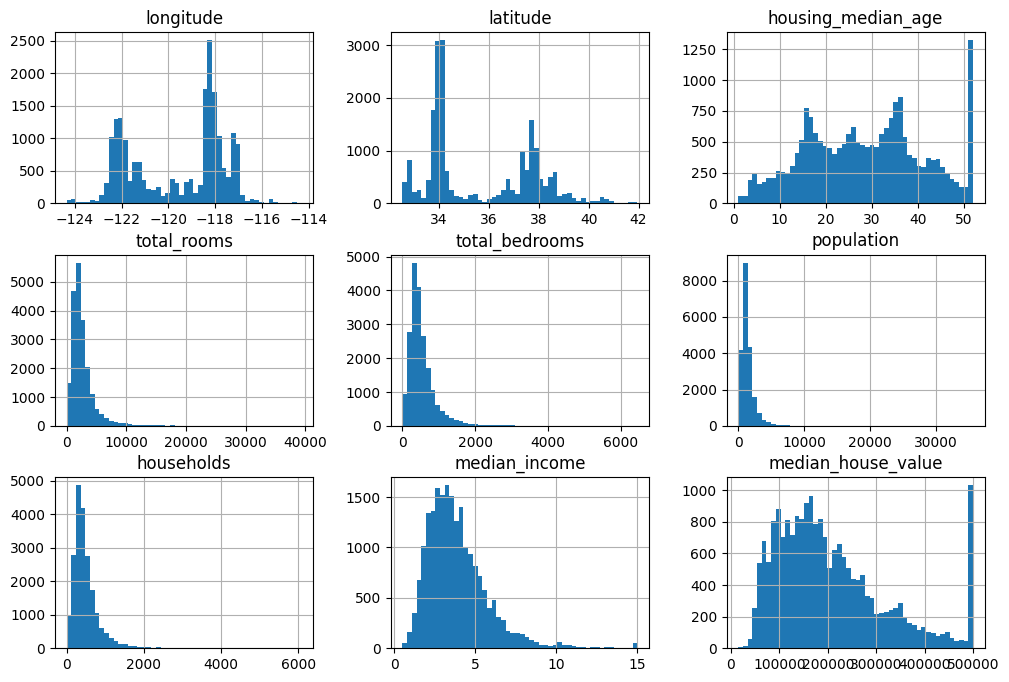

In [6]:
#Q5
housing.hist(bins=50, figsize=(12,8))

In [9]:
#Q6
import numpy as np

housing["income_cat"] = pd.cut(
    housing["median_income"],
    bins=[0.,1.5,3.0,4.5,6.,np.inf],
    labels=[1,2,3,4,5]
)

In [11]:
housing["income_cat"].value_counts()

income_cat
3    7236
2    6581
4    3639
5    2362
1     822
Name: count, dtype: int64

In [13]:
#Q7

corr_matrix = housing.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

The feature with the highest correlation is median_income with a correlation value of approximately 0.688.

<Axes: xlabel='median_income', ylabel='median_house_value'>

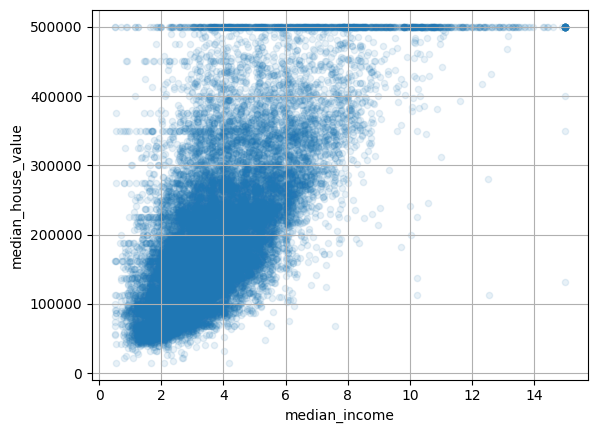

In [14]:
#Q8
housing.plot(
    kind="scatter",
    x="median_income",
    y="median_house_value",
    alpha=0.1,
    grid=True
)

Yes, there is a positive correlation between median_income and median_house_value. As the median income increases, the median house value generally increases as well.

In [16]:
#Q9
from sklearn.impute import SimpleImputer
SimpleImputer(strategy="median")

SimpleImputer(strategy='median')

In [19]:
OneHotEncoder()

OneHotEncoder()

In [21]:
housing["bedrooms_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]

housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]

housing["people_per_house"] = housing["population"] / housing["households"]

In [22]:
housing[["bedrooms_ratio","rooms_per_house","people_per_house"]].head()

,bedrooms_ratio,rooms_per_house,people_per_house
0,0.146591,6.984127,2.555556
1,0.155797,6.238137,2.109842
2,0.129516,8.288136,2.802260
3,0.184458,5.817352,2.547945
4,0.172096,6.281853,2.181467


In [24]:
kmeans = KMeans(n_clusters=10, random_state=0)
kmeans.fit(housing[["latitude", "longitude"]])

KMeans(n_clusters=10, random_state=0)

In [30]:
class ClusterSimilarity(BaseEstimator, TransformerMixin):

    def __init__(self, n_clusters=10, gamma=1.0, random_state=0):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None):
        self.kmeans_ = KMeans(
            self.n_clusters,
            random_state=self.random_state
        )
        self.kmeans_.fit(X)
        return self

    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)

In [31]:
cluster_sim = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=0)

cluster_features = cluster_sim.fit_transform(
    housing[["latitude","longitude"]]
)

In [32]:
for i in range(cluster_features.shape[1]):
    housing[f"cluster_sim_{i}"] = cluster_features[:, i]

In [34]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,...,cluster_sim_0,cluster_sim_1,cluster_sim_2,cluster_sim_3,cluster_sim_4,cluster_sim_5,cluster_sim_6,cluster_sim_7,cluster_sim_8,cluster_sim_9
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,...,1.790255e-13,0.553469,0.000301,0.147146,1.406988e-23,0.000619,4.059887e-07,0.991098,2.184634e-18,8.787621e-16
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,...,2.250053e-13,0.570990,0.000332,0.144457,1.908483e-23,0.000549,4.790789e-07,0.987548,2.815521e-18,1.124204e-15
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,...,2.078408e-13,0.563094,0.000307,0.136079,1.709665e-23,0.000538,4.586025e-07,0.989909,2.472841e-18,1.025139e-15
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,...,1.923108e-13,0.556375,0.000292,0.133329,1.538983e-23,0.000547,4.358959e-07,0.991369,2.231148e-18,9.403211e-16
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,...,1.923108e-13,0.556375,0.000292,0.133329,1.538983e-23,0.000547,4.358959e-07,0.991369,2.231148e-18,9.403211e-16


In [33]:
housing.filter(like="cluster").head()

,cluster_0,cluster_1,cluster_2,cluster_3,cluster_4,cluster_5,cluster_6,cluster_7,cluster_8,cluster_9,cluster_sim_0,cluster_sim_1,cluster_sim_2,cluster_sim_3,cluster_sim_4,cluster_sim_5,cluster_sim_6,cluster_sim_7,cluster_sim_8,cluster_sim_9
0,0.053124,0.942561,0.444460,0.825610,0.005186,0.477739,0.229536,0.999106,0.017137,0.031217,1.790255e-13,0.553469,0.000301,0.147146,1.406988e-23,0.000619,4.059887e-07,0.991098,2.184634e-18,8.787621e-16
1,0.054352,0.945503,0.448909,0.824089,0.005346,0.472019,0.233368,0.998748,0.017577,0.031995,2.250053e-13,0.570990,0.000332,0.144457,1.908483e-23,0.000549,4.790789e-07,0.987548,2.815521e-18,1.124204e-15
2,0.053923,0.944187,0.445366,0.819179,0.005288,0.471067,0.232351,0.998986,0.017351,0.031701,2.078408e-13,0.563094,0.000307,0.136079,1.709665e-23,0.000538,4.586025e-07,0.989909,2.472841e-18,1.025139e-15
3,0.053506,0.943054,0.443064,0.817509,0.005233,0.471813,0.231174,0.999133,0.017173,0.031429,1.923108e-13,0.556375,0.000292,0.133329,1.538983e-23,0.000547,4.358959e-07,0.991369,2.231148e-18,9.403211e-16
4,0.053506,0.943054,0.443064,0.817509,0.005233,0.471813,0.231174,0.999133,0.017173,0.031429,1.923108e-13,0.556375,0.000292,0.133329,1.538983e-23,0.000547,4.358959e-07,0.991369,2.231148e-18,9.403211e-16


Cluster similarity features were created by clustering housing districts based on their latitude and longitude values using the ClusterSimilarity transformer with 10 clusters. The similarity between each district and the cluster centers was computed and added to the dataset as new features.

In [36]:
#Q10
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(
    housing,
    test_size=0.2,
    stratify=housing["income_cat"],
    random_state=0
)
print(len(train_set), len(test_set))

16512 4128


The dataset was split into training and test sets using the train_test_split method.
20% of the data was used as the test set and stratified sampling was applied based on the income_cat feature to preserve the income distribution. The random_state parameter was set to 0 to ensure reproducibility.

In [40]:
#Q11
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

X_train = train_set.drop(["median_house_value","ocean_proximity"], axis=1)
y_train = train_set["median_house_value"]

X_test = test_set.drop(["median_house_value","ocean_proximity"], axis=1)
y_test = test_set["median_house_value"]

In [41]:
model = RandomForestRegressor(random_state=0)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(rmse)

48250.11884448209


RMSE score is 48250.11884448209

In [42]:
#Q12
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    model,
    X_train,
    y_train,
    scoring="neg_mean_squared_error",
    cv=10
)

rmse_scores = np.sqrt(-scores)

print("Mean RMSE:", rmse_scores.mean())
print("Standard Deviation:", rmse_scores.std())

Mean RMSE: 46579.244702868826
Standard Deviation: 1514.9799491343526


The mean RMSE obtained from the cross validation is 46579.24, and the standard deviation of the RMSE scores is 1514.98.